# AI651 PA1, Task 2: Autoformer, attempt 3 (final)

Leaderboard attempt 3, the final submission. An Autoformer with a **non-linear exogenous head** and a **floor layer**, `max(output, 14.7)`, that is part of the network during training. Three seeds are refit on the full history and averaged.

**Leaderboard:** RMSE 67.22 (rank 3).

The Auto-Correlation and series-decomposition layers (`../autoformer/`) come from [thuml/Autoformer](https://github.com/thuml/Autoformer) (MIT licence). Everything else is defined in this notebook.

In [1]:
import json, os, sys, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

HERE = os.path.abspath("")
ROOT = os.path.dirname(HERE)
sys.path.insert(0, ROOT)
from autoformer.AutoCorrelation import AutoCorrelation, AutoCorrelationLayer
from autoformer.Autoformer_EncDec import (Encoder, Decoder, EncoderLayer, DecoderLayer,
                                          my_Layernorm, series_decomp)

DATA = os.path.join(ROOT, "Data")
RES = os.path.join(HERE, "results")
RUN_DIR = os.path.join(RES, "runs")
FIG = os.path.join(HERE, "figures")
os.makedirs(RUN_DIR, exist_ok=True); os.makedirs(FIG, exist_ok=True)
torch.set_num_threads(max(1, os.cpu_count() // 2))

RUN_EXPERIMENTS = False  # True retrains every run from scratch; False loads the saved models in results/runs

## 1. Configuration and chronological split
Train on steps 1–37,608. The next 12 weeks (37,609–39,624) are for early stopping only. The final **24 non-overlapping 168-step weeks** (39,625–43,656) are held out for evaluation; weeks 12–23 are the most recent and most volatile.

In [2]:
SEQ_LEN, LABEL_LEN, PRED_LEN = 168, 48, 168
N_HIST = 43656
N_EVAL_BLOCKS, N_ES_BLOCKS = 24, 12
EVAL_START = N_HIST - N_EVAL_BLOCKS * PRED_LEN
ES_START = EVAL_START - N_ES_BLOCKS * PRED_LEN
EVAL_ORIGINS = [EVAL_START + k * PRED_LEN for k in range(N_EVAL_BLOCKS)]
PERIODS = (24.0, 8766.0)
SEEDS = [0, 1, 2]
CONT = ["feature_A", "feature_B", "feature_C", "feature_D", "feature_E", "feature_F"]
BIN = ["feature_G", "feature_H", "feature_I", "feature_J"]
LOG_COLS = ["feature_D", "feature_E", "feature_F"]

CFG = {"model": dict(d_model=32, n_heads=4, e_layers=1, d_layers=1, d_ff=64, moving_avg=25,
                     factor=1, dropout=0.25),
       "train": dict(batch=64, lr=3e-4, exo_lr=3e-3, max_epochs=15, patience=4, train_stride=2,
                     weight_decay=1e-4, schedule="cosine")}

## 2. Data
* **Phase features** stand in for the missing calendar: sin/cos at the 24-step and ~8,766-step periods found in the periodogram.
* **Covariates:** `log1p` on the heavy-tailed counters D–F; the continuous features are standardised on the training region; the one-hot flags G–J stay as 0/1.
* Covariates enter the **encoder** over the input window and the **decoder** over the label window and the forecast horizon, since the external file covers the horizon.

In [3]:
def load():
    y = pd.read_csv(os.path.join(DATA, "student_train.csv"))["value"].to_numpy(float)
    X = pd.read_csv(os.path.join(DATA, "optional_external_data.csv"))
    assert len(y) == N_HIST and len(X) == N_HIST + PRED_LEN
    t = X["time_idx"].to_numpy(float)
    phase = np.concatenate([np.stack([np.sin(2 * np.pi * t / p), np.cos(2 * np.pi * t / p)], 1)
                            for p in PERIODS], 1).astype(np.float32)
    cov = X[CONT + BIN].copy()
    for c in LOG_COLS:
        cov[c] = np.log1p(cov[c])
    cov = cov.to_numpy(float)
    mu, sd = cov[:ES_START].mean(0), cov[:ES_START].std(0) + 1e-8
    mu[len(CONT):], sd[len(CONT):] = 0.0, 1.0
    cov = ((cov - mu) / sd).astype(np.float32)
    return y, phase, cov, X


class Scaler:
    def __init__(self, y):
        self.m, self.s = float(y[:ES_START].mean()), float(y[:ES_START].std())
    def f(self, v): return (v - self.m) / self.s
    def inv(self, v): return v * self.s + self.m


def make_batch(origins, ys, menc, mdec):
    xe = np.stack([ys[o - SEQ_LEN:o] for o in origins])[..., None]
    me = np.stack([menc[o - SEQ_LEN:o] for o in origins])
    md = np.stack([mdec[o - LABEL_LEN:o + PRED_LEN] for o in origins])
    return torch.tensor(xe), torch.tensor(me), torch.tensor(md)


def target(origins, ys):
    return torch.tensor(np.stack([ys[o:o + PRED_LEN] for o in origins])[..., None])

y, phase, cov, X = load()
sc = Scaler(y)
ys = sc.f(y).astype(np.float32)
marks = np.concatenate([phase, cov], 1)
FLOOR = float(np.percentile(y[:ES_START], 10))
truth = np.stack([y[o:o + PRED_LEN] for o in EVAL_ORIGINS])
print(f"history {len(y):,} steps; marks {marks.shape}" + f"; floor {FLOOR:.2f}")

history 43,656 steps; marks (43824, 14); floor 14.70


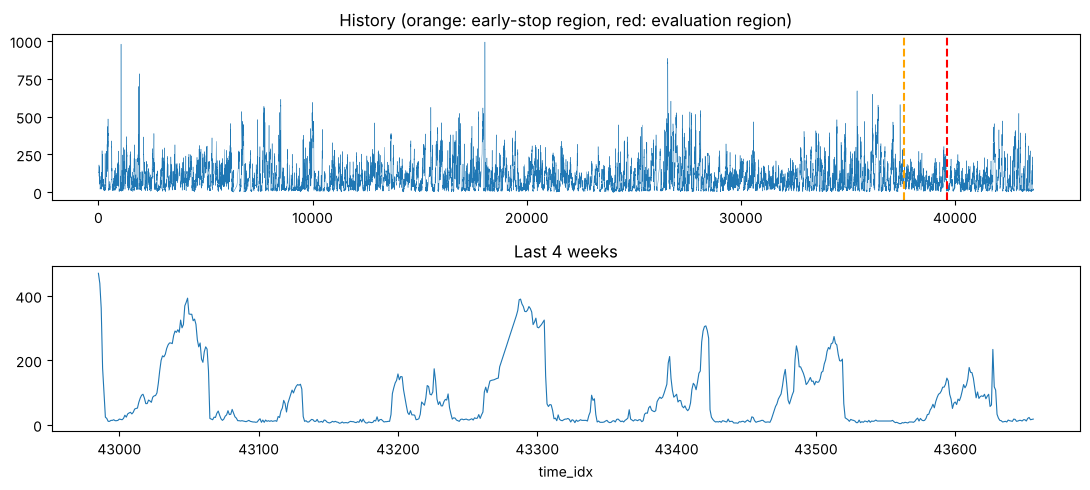

In [4]:
fig, ax = plt.subplots(2, 1, figsize=(11, 5))
ax[0].plot(np.arange(1, len(y) + 1), y, lw=0.3)
for s, c in [(ES_START, "orange"), (EVAL_START, "red")]:
    ax[0].axvline(s, color=c, ls="--")
ax[0].set_title("History (orange: early-stop region, red: evaluation region)")
ax[1].plot(np.arange(len(y) - 672, len(y)) + 1, y[-672:], lw=0.8)
ax[1].set_title("Last 4 weeks"); ax[1].set_xlabel("time_idx")
plt.tight_layout(); plt.savefig(f"{FIG}/series.pdf"); plt.show()

Top periodogram periods: [np.float64(10914.0), np.float64(2910.4), np.float64(8731.2), np.float64(269.5), np.float64(24.0), np.float64(7276.0), np.float64(386.3), np.float64(183.4)]
ACF at lags 1, 6, 24, 48, 168: [0.966 0.749 0.402 0.158 0.028]


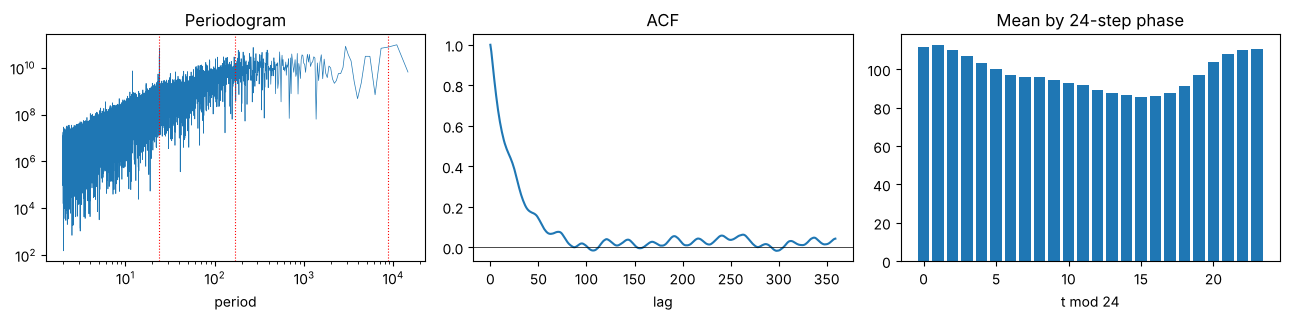

In [5]:
z = y - y.mean()
P = np.abs(np.fft.rfft(z)) ** 2; f = np.fft.rfftfreq(len(z))
print("Top periodogram periods:", [round(1 / f[i], 1) for i in np.argsort(P[1:])[::-1][:8] + 1])
lags = np.arange(0, 360)
acf = np.array([1.0] + [np.corrcoef(z[:-l], z[l:])[0, 1] for l in lags[1:]])
print("ACF at lags 1, 6, 24, 48, 168:", acf[[1, 6, 24, 48, 168]].round(3))
prof = pd.Series(y).groupby(np.arange(len(y)) % 24).mean()
fig, ax = plt.subplots(1, 3, figsize=(13, 3.3))
per = 1 / f[1:]; m = (per > 2) & (per < 20000)
ax[0].loglog(per[m], P[1:][m], lw=0.5); ax[0].set_xlabel("period"); ax[0].set_title("Periodogram")
for p in (24, 168, 8766): ax[0].axvline(p, color="r", ls=":", lw=0.8)
ax[1].plot(lags, acf); ax[1].axhline(0, c="k", lw=0.5); ax[1].set_xlabel("lag"); ax[1].set_title("ACF")
ax[2].bar(prof.index, prof.values); ax[2].set_xlabel("t mod 24"); ax[2].set_title("Mean by 24-step phase")
plt.tight_layout(); plt.savefig(f"{FIG}/periodicity.pdf"); plt.show()

In [6]:
Xh = X.iloc[:N_HIST]
pd.DataFrame({c: {"corr(level)": np.corrcoef(Xh[c], y)[0, 1],
                  "corr(diff)": np.corrcoef(np.diff(Xh[c]), np.diff(y))[0, 1]}
              for c in CONT + BIN}).T.round(3)

,corr(level),corr(diff)
feature_A,0.169,0.139
feature_B,-0.088,-0.067
feature_C,-0.048,-0.004
feature_D,-0.245,-0.024
feature_E,0.019,-0.004
feature_F,-0.050,-0.016
feature_G,-0.033,-0.009
feature_H,-0.212,0.003
feature_I,0.097,0.000
feature_J,0.154,0.004


## 3. Model
* **Autoformer body**, following the reference wiring: input decomposition (moving average, kernel 25); a trend initialised from the window mean and a seasonal part from zeros; Auto-Correlation in the encoder and in both decoder attentions (top k = ⌊ln L⌋ delays); decomposition after every block, with the trend accumulated through the decoder.
* **Embedding:** a circular-conv value embedding plus a linear map of the marks. There is no positional encoding: Auto-Correlation works on time-shifted copies of the whole series, and the phase features give absolute time.
* **Exogenous head:** a 5-step convolution, a GELU and a 1×1 convolution over the decoder marks (1,153 parameters). It adds a covariate-driven term at each forecast step and reacts to changes in the covariates, not only their levels.
* **Floor layer:** `max(output, floor)` as the last operation, where the floor is 14.7, the 10th percentile of the training target. The series is essentially never 0, so values below this level are implausible. The layer has no parameters, and because it sits inside the network, training never rewards outputs below the floor.

In [7]:
class Embedding(nn.Module):
    def __init__(self, c_in, mark_dim, d_model, dropout):
        super().__init__()
        self.value = nn.Conv1d(c_in, d_model, 3, padding=1, padding_mode="circular", bias=False)
        self.mark = nn.Linear(mark_dim, d_model, bias=False)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, m):
        return self.drop(self.value(x.permute(0, 2, 1)).transpose(1, 2) + self.mark(m))


class Autoformer(nn.Module):
    def __init__(self, enc_mark, dec_mark, d_model, n_heads, e_layers, d_layers, d_ff, moving_avg, factor, dropout, floor_std=0.0):
        super().__init__()
        self.register_buffer("floor_std", torch.tensor(float(floor_std)))
        self.exo = nn.Sequential(nn.Conv1d(dec_mark, 16, 5, padding=2), nn.GELU(), nn.Conv1d(16, 1, 1))
        self.decomp = series_decomp(moving_avg)
        self.enc_emb = Embedding(1, enc_mark, d_model, dropout)
        self.dec_emb = Embedding(1, dec_mark, d_model, dropout)
        AC = lambda mask: AutoCorrelationLayer(
            AutoCorrelation(mask, factor, attention_dropout=dropout), d_model, n_heads)
        self.encoder = Encoder([EncoderLayer(AC(False), d_model, d_ff, moving_avg=moving_avg,
                                             dropout=dropout, activation="gelu")
                                for _ in range(e_layers)], norm_layer=my_Layernorm(d_model))
        self.decoder = Decoder([DecoderLayer(AC(True), AC(False), d_model, 1, d_ff,
                                             moving_avg=moving_avg, dropout=dropout, activation="gelu")
                                for _ in range(d_layers)], norm_layer=my_Layernorm(d_model),
                               projection=nn.Linear(d_model, 1, bias=True))

    def forward(self, x, m_enc, m_dec):
        mean = x.mean(1, keepdim=True).repeat(1, PRED_LEN, 1)
        zeros = torch.zeros(x.shape[0], PRED_LEN, 1)
        seasonal, trend = self.decomp(x)
        trend_init = torch.cat([trend[:, -LABEL_LEN:], mean], 1)
        seas_init = torch.cat([seasonal[:, -LABEL_LEN:], zeros], 1)
        enc, _ = self.encoder(self.enc_emb(x, m_enc))
        s, t = self.decoder(self.dec_emb(seas_init, m_dec), enc, trend=trend_init)
        out = (s + t)[:, -PRED_LEN:]
        out = out + self.exo(m_dec.transpose(1, 2)).transpose(1, 2)[:, -PRED_LEN:]
        return torch.maximum(out, self.floor_std)


def n_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def build_model(menc, mdec, cfg):
    return Autoformer(menc.shape[1], mdec.shape[1], **cfg["model"], floor_std=sc.f(FLOOR))


print(f"trainable parameters per model: {n_params(build_model(marks, marks, CFG)):,}")

trainable parameters per model: 23,362


## 4. Training
MSE loss on the standardised target and AdamW (weight decay 1e-4; learning rate 3e-4 for the body, 3e-3 for the head) with a cosine schedule; dropout 0.25; batch 64; training windows every 2 steps; early stopping with patience 4 (maximum 15 epochs).

In [8]:
def predict(model, origins, series, menc, mdec, lower=0.0):
    model.eval(); out = []
    with torch.no_grad():
        for i in range(0, len(origins), 256):
            out.append(model(*make_batch(origins[i:i + 256], series, menc, mdec)).squeeze(-1).numpy())
    return np.clip(sc.inv(np.concatenate(out)), lower, None)


def train(seed, menc, mdec, cfg, train_end=ES_START, early_stop=True, epochs=None, verbose=True):
    torch.manual_seed(seed); np.random.seed(seed)
    model = build_model(menc, mdec, cfg)
    t_cfg = cfg["train"]
    exo_ids = {id(p) for p in model.exo.parameters()}
    opt = torch.optim.AdamW(
        [{"params": [p for p in model.parameters() if id(p) not in exo_ids], "lr": t_cfg["lr"]},
         {"params": list(model.exo.parameters()), "lr": t_cfg["exo_lr"]}],
        weight_decay=t_cfg["weight_decay"])
    max_ep = epochs or t_cfg["max_epochs"]
    sched = (torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max_ep)
             if t_cfg["schedule"] == "cosine" else None)
    lossf = nn.MSELoss()
    tr = np.arange(SEQ_LEN, train_end - PRED_LEN + 1, t_cfg["train_stride"])
    es_orig = np.arange(ES_START, EVAL_START - PRED_LEN + 1, 24)
    best, best_ep, bad, state, hist = np.inf, 0, 0, None, []
    rng = np.random.default_rng(seed)
    for ep in range(1, max_ep + 1):
        model.train(); t0 = time.time(); perm = rng.permutation(tr); tl = []
        for i in range(0, len(perm), t_cfg["batch"]):
            o = perm[i:i + t_cfg["batch"]]
            loss = lossf(model(*make_batch(o, ys, menc, mdec)), target(o, ys))
            opt.zero_grad(); loss.backward(); opt.step(); tl.append(loss.item())
        if sched is not None:
            sched.step()
        else:
            for g in opt.param_groups:
                g["lr"] *= 0.5
        rec = dict(epoch=ep, train_loss=float(np.mean(tl)), sec=round(time.time() - t0, 1))
        if early_stop:
            model.eval()
            with torch.no_grad():
                vl = float(np.mean([lossf(model(*make_batch(es_orig[i:i + 256], ys, menc, mdec)),
                                          target(es_orig[i:i + 256], ys)).item()
                                    for i in range(0, len(es_orig), 256)]))
            rec["es_loss"] = vl
            if vl < best - 1e-4:
                best, best_ep, bad = vl, ep, 0
                state = {k: v.clone() for k, v in model.state_dict().items()}
            else:
                bad += 1
        hist.append(rec)
        if verbose:
            print(json.dumps(rec))
        if early_stop and bad >= t_cfg["patience"]:
            break
    if early_stop:
        model.load_state_dict(state)
    return model, dict(history=hist, best_epoch=best_ep if early_stop else max_ep, epochs_run=len(hist))


def metrics(t, p):
    d = np.abs(t - p)
    return dict(MAE=float(d.mean()), RMSE=float(np.sqrt(np.mean(d ** 2))),
                sMAPE=float(np.mean(200 * d / (np.abs(t) + np.abs(p) + 1e-12))))


def week_scores(preds):
    """Per-week metrics averaged over the 24 evaluation weeks, plus RMSE on weeks 12-23."""
    w = [metrics(truth[k], preds[k]) for k in range(N_EVAL_BLOCKS)]
    out = {m: float(np.mean([r[m] for r in w])) for m in ("MAE", "RMSE", "sMAPE")}
    out["RMSE weeks 12-23"] = float(np.mean([r["RMSE"] for r in w[12:]]))
    return out

## 5. Validation (3 seeds)
Each seed is trained with early stopping and scored on the 24 held-out weeks. Metrics are computed per week, then averaged.

In [9]:
runs = {}
for s in SEEDS:
    path = os.path.join(RUN_DIR, f"s{s}")
    if RUN_EXPERIMENTS:
        model, info = train(s, marks, marks, CFG)
        torch.save(model.state_dict(), path + ".pt")
    else:
        model = build_model(marks, marks, CFG); model.load_state_dict(torch.load(path + ".pt"))
        saved = json.load(open(path + ".json"))
        info = {k: saved[k] for k in ("history", "best_epoch", "epochs_run")}
    preds = predict(model, EVAL_ORIGINS, ys, marks, marks)
    json.dump(dict(info, preds=preds.round(2).tolist()), open(path + ".json", "w"))
    runs[s] = dict(info, preds=preds)

rows = [{"seed": s, **week_scores(runs[s]["preds"]), "best epoch": runs[s]["best_epoch"],
         "epochs run": runs[s]["epochs_run"]} for s in SEEDS]
ens = np.mean([runs[s]["preds"] for s in SEEDS], 0)
rows.append({"seed": "3-seed average", **week_scores(ens)})
val = pd.DataFrame(rows).set_index("seed")
val.to_latex(os.path.join(RES, "table_validation.tex"), float_format="%.2f")
val.round(2)

,MAE,RMSE,sMAPE,RMSE weeks 12-23,best epoch,epochs run
seed,,,,,,
0,44.52,60.10,51.74,72.89,1.0,5.0
1,41.63,55.98,51.93,69.72,1.0,5.0
2,39.80,54.24,52.28,67.08,1.0,5.0
3-seed average,40.01,54.26,49.32,68.34,NaN,NaN


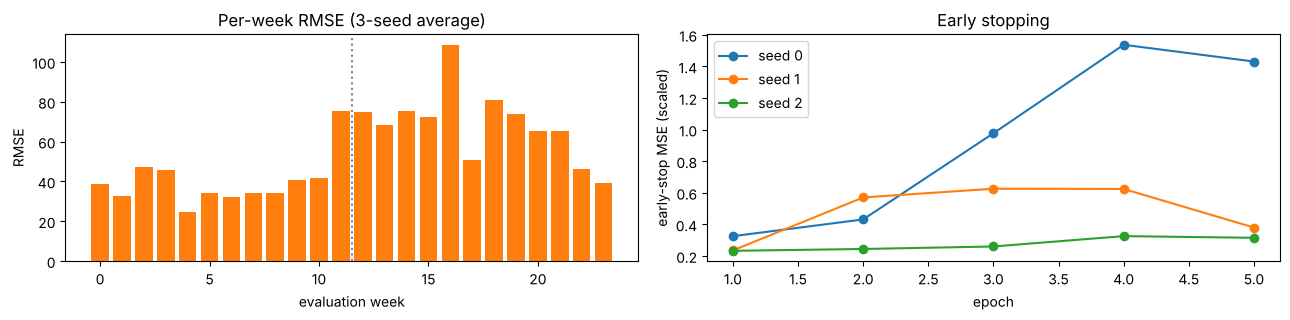

In [10]:
week_rmse = np.array([metrics(truth[k], ens[k])["RMSE"] for k in range(N_EVAL_BLOCKS)])
fig, ax = plt.subplots(1, 2, figsize=(13, 3.3))
ax[0].bar(np.arange(24), week_rmse, color="C1"); ax[0].axvline(11.5, c="gray", ls=":")
ax[0].set_xlabel("evaluation week"); ax[0].set_ylabel("RMSE"); ax[0].set_title("Per-week RMSE (3-seed average)")
for s in SEEDS:
    h = runs[s]["history"]
    ax[1].plot([r["epoch"] for r in h], [r["es_loss"] for r in h], marker="o", label=f"seed {s}")
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("early-stop MSE (scaled)"); ax[1].set_title("Early stopping"); ax[1].legend()
plt.tight_layout(); plt.savefig(f"{FIG}/validation.pdf"); plt.show()

## 6. Final forecast
Each seed is refit on the **full history** for the epoch count its early-stopped run chose, and the three forecasts are averaged.

* **P** = sum of trainable parameters over the 3 models.
* **E** = for each seed, the early-stopping epochs run plus the refit epochs (PDF §2.7).

In [11]:
LOWER = 0.0
ys_full = np.concatenate([ys, np.zeros(PRED_LEN, dtype=np.float32)])
forecasts, P_total, E_total = [], 0, 0
for s in SEEDS:
    path = os.path.join(RUN_DIR, f"s{s}_refit.pt")
    if RUN_EXPERIMENTS:
        model, _ = train(s, marks, marks, CFG, train_end=N_HIST, early_stop=False, epochs=runs[s]["best_epoch"])
        torch.save(model.state_dict(), path)
    else:
        model = build_model(marks, marks, CFG); model.load_state_dict(torch.load(path))
    forecasts.append(predict(model, [N_HIST], ys_full, marks, marks, lower=LOWER)[0])
    P_total += n_params(model)
    E_total += runs[s]["epochs_run"] + runs[s]["best_epoch"]
forecast = np.mean(forecasts, 0)
assert len(forecast) == PRED_LEN and np.all(np.isfinite(forecast))
submission = ", ".join(f"{v:.2f}" for v in forecast)
open(os.path.join(RES, "submission.txt"), "w").write(submission + "\n")
pd.DataFrame({"time_idx": np.arange(N_HIST + 1, N_HIST + PRED_LEN + 1), "value": forecast}) \
    .to_csv(os.path.join(RES, "submission_forecast.csv"), index=False)
json.dump({"P": P_total, "E": E_total}, open(os.path.join(RES, "submission_meta.json"), "w"), indent=1)
print(f"P = {P_total}   E = {E_total}")
print(submission)

P = 70086   E = 18
14.70, 14.70, 14.70, 14.70, 14.70, 14.70, 14.70, 14.70, 14.70, 14.70, 14.70, 14.70, 14.70, 14.70, 14.70, 14.70, 16.85, 61.62, 102.72, 119.30, 125.89, 123.11, 116.78, 124.61, 126.97, 120.48, 138.75, 167.99, 177.52, 178.88, 162.50, 147.78, 137.64, 136.14, 146.89, 145.25, 153.59, 163.68, 155.53, 151.88, 163.24, 169.37, 196.45, 222.09, 243.86, 226.27, 228.15, 233.49, 229.82, 214.10, 197.95, 179.44, 165.83, 152.96, 144.73, 141.69, 132.11, 116.28, 95.62, 92.13, 82.06, 80.62, 95.70, 128.77, 140.61, 158.50, 171.40, 181.22, 209.14, 221.59, 226.83, 230.56, 241.19, 243.56, 244.17, 232.03, 203.29, 176.84, 154.07, 130.33, 125.57, 124.57, 118.34, 89.27, 55.85, 36.26, 32.79, 24.88, 21.13, 23.44, 34.85, 53.83, 90.61, 141.72, 208.63, 213.87, 214.96, 210.28, 194.99, 176.42, 172.97, 173.94, 165.93, 169.08, 180.80, 173.75, 169.74, 153.06, 115.76, 75.59, 25.70, 14.70, 14.70, 18.88, 35.51, 85.42, 166.36, 190.48, 201.50, 209.02, 209.92, 203.15, 190.19, 158.22, 129.29, 110.02, 91.21, 83.24,

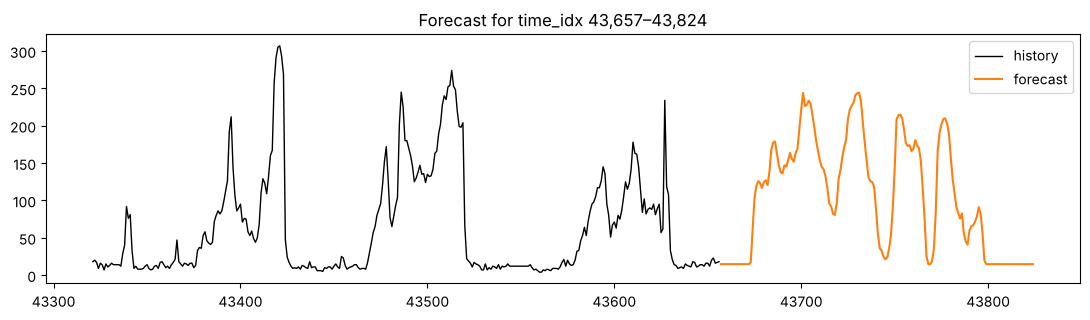

In [12]:
plt.figure(figsize=(11, 3.3))
plt.plot(np.arange(N_HIST - 336, N_HIST) + 1, y[-336:], c="k", lw=1, label="history")
plt.plot(np.arange(N_HIST + 1, N_HIST + PRED_LEN + 1), forecast, c="C1", label="forecast")
plt.legend(); plt.title("Forecast for time_idx 43,657–43,824")
plt.tight_layout(); plt.savefig(f"{FIG}/forecast.pdf"); plt.show()